# Premise Behind this Strategy
The VIX is a measure of volatilty. High volatilty creates high fear, high fear drives uncertainty, and uncertainty creates mispricings.
It is also known that US equities tend to trend upward and volatilty tends to mean revert. 
Therefore is it plausible to construct a strategy that uses volatility to invest more accurately?

In [63]:

import pandas as pd
import numpy as np
import yfinance as yf
from datetime import datetime
import warnings
import matplotlib.pyplot as plt
warnings.filterwarnings('ignore')
LUMP_SUM = 5000
print("=" * 80)
print("Downloading Real Market Data from Yahoo Finance")
print("=" * 80)

# Download SPY (S&P 500 ETF) data
print("\nDownloading SPY data...")
spy = yf.download('SPY', start='2012-01-29', end='2025-10-11', progress=False)
print(f"✓ SPY data downloaded: {len(spy)} rows")

# Download VIX (CBOE Volatility Index) data
print("\nDownloading VIX data...")
vix = yf.download('^VIX', start='2012-01-29', end='2025-10-11', progress=False)
print(f"✓ VIX data downloaded: {len(vix)} rows")

# Combine the data - FIXED: Handle MultiIndex columns properly
print("\nProcessing and merging data...")

# Check if the data has MultiIndex columns (newer yfinance versions)
if isinstance(spy.columns, pd.MultiIndex):
    spy_close = spy['Close'].iloc[:, 0] if isinstance(spy['Close'], pd.DataFrame) else spy['Close']
    vix_close = vix['Close'].iloc[:, 0] if isinstance(vix['Close'], pd.DataFrame) else vix['Close']
else:
    spy_close = spy['Close']
    vix_close = vix['Close']

# Create DataFrame
df = pd.DataFrame({
    'SPY': spy_close,
    'VIX': vix_close
})

# Remove any rows with missing data
df = df.dropna()

# Basic data info
print("\n" + "=" * 80)
print("DATA SUMMARY")
print("=" * 80)
print(f"\nData Range: {df.index[0].date()} to {df.index[-1].date()}")
print(f"Total Trading Days: {len(df):,}")

print(f"\n📊 VIX Statistics:")
print(f"  Mean: {df['VIX'].mean():.2f}")
print(f"  Median: {df['VIX'].median():.2f}")
print(f"  Max: {df['VIX'].max():.2f} on {df['VIX'].idxmax().date()}")
print(f"  Min: {df['VIX'].min():.2f} on {df['VIX'].idxmin().date()}")
print(f"  Standard Deviation: {df['VIX'].std():.2f}")

# VIX threshold analysis
VIX_THRESHOLD = 50
print(f"\n  Days where VIX > {VIX_THRESHOLD}: {(df['VIX'] > VIX_THRESHOLD).sum()}")
print(f"  Days where VIX > 40: {(df['VIX'] > 40).sum()}")
print(f"  Days where VIX > 30: {(df['VIX'] > 30).sum()}")

print(f"\n📈 SPY Statistics:")
print(f"  Starting Price: ${df['SPY'].iloc[0]:.2f}")
print(f"  Ending Price: ${df['SPY'].iloc[-1]:.2f}")
print(f"  All-Time High: ${df['SPY'].max():.2f} on {df['SPY'].idxmax().date()}")
print(f"  All-Time Low: ${df['SPY'].min():.2f} on {df['SPY'].idxmin().date()}")

# Calculate returns
total_return = ((df['SPY'].iloc[-1] / df['SPY'].iloc[0]) - 1) * 100
years = (df.index[-1] - df.index[0]).days / 365.25
annualized_return = ((df['SPY'].iloc[-1] / df['SPY'].iloc[0]) ** (1/years) - 1) * 100

print(f"  Total Return: {total_return:.2f}%")
print(f"  Annualized Return: {annualized_return:.2f}%")

# Show major VIX spike periods
print(f"\n📅 Major VIX Spikes (VIX > {VIX_THRESHOLD}):")
print("-" * 80)

high_vix_df = df[df['VIX'] > VIX_THRESHOLD].copy()

if len(high_vix_df) > 0:
    # Group consecutive periods (allowing 5-day gaps)
    high_vix_df['date_diff'] = high_vix_df.index.to_series().diff()
    high_vix_df['new_period'] = high_vix_df['date_diff'] > pd.Timedelta(days=5)
    high_vix_df['period_group'] = high_vix_df['new_period'].cumsum()
    
    period_count = 0
    for period_id, period_data in high_vix_df.groupby('period_group'):
        period_count += 1
        start_date = period_data.index[0]
        end_date = period_data.index[-1]
        max_vix = period_data['VIX'].max()
        max_vix_date = period_data['VIX'].idxmax()
        
        # Get SPY prices
        spy_start = df.loc[start_date, 'SPY']
        spy_end = df.loc[end_date, 'SPY']
        spy_change = ((spy_end / spy_start) - 1) * 100
        
        print(f"Period {period_count}:")
        print(f"  Dates: {start_date.date()} to {end_date.date()} ({len(period_data)} days)")
        print(f"  Peak VIX: {max_vix:.2f} on {max_vix_date.date()}")
        print(f"  SPY: ${spy_start:.2f} → ${spy_end:.2f} ({spy_change:+.2f}%)")
        print()
else:
    print(f"  No periods found with VIX > {VIX_THRESHOLD}")

# Save the data
df.to_csv('spy_vix_real_data.csv')
print("=" * 80)
print("💾 Data saved to 'spy_vix_real_data.csv'")
print("=" * 80)
print("\n✓ Real market data download complete!")
print("✓ Ready for backtesting analysis")





✓ SPY data downloaded: 3446 rows

✓ VIX data downloaded: 3446 rows

Processing and merging data...

DATA SUMMARY

Data Range: 2012-01-30 to 2025-10-10
Total Trading Days: 3,446

📊 VIX Statistics:
  Mean: 17.69
  Median: 15.97
  Max: 82.69 on 2020-03-16
  Min: 9.14 on 2017-11-03
  Standard Deviation: 6.63

  Days where VIX > 50: 19
  Days where VIX > 40: 40
  Days where VIX > 30: 156

📈 SPY Statistics:
  Starting Price: $102.91
  Ending Price: $653.02
  All-Time High: $673.11 on 2025-10-08
  All-Time Low: $100.79 on 2012-06-04
  Total Return: 534.56%
  Annualized Return: 14.45%

📅 Major VIX Spikes (VIX > 50):
--------------------------------------------------------------------------------
Period 1:
  Dates: 2020-03-09 to 2020-04-02 (18 days)
  Peak VIX: 82.69 on 2020-03-16
  SPY: $252.04 → $232.81 (-7.63%)

Period 2:
  Dates: 2025-04-08 to 2025-04-08 (1 days)
  Peak VIX: 52.33 on 2025-04-08
  SPY: $493.65 → $493.65 (+0.00%)

💾 Data saved to 'spy_vix_real_data.csv'

✓ Real market data d

In this example, we use a VIX of 50 to mark a buy signal. The Vix, the first graph shown below, clearly reverts to some sort of "mean" level. 

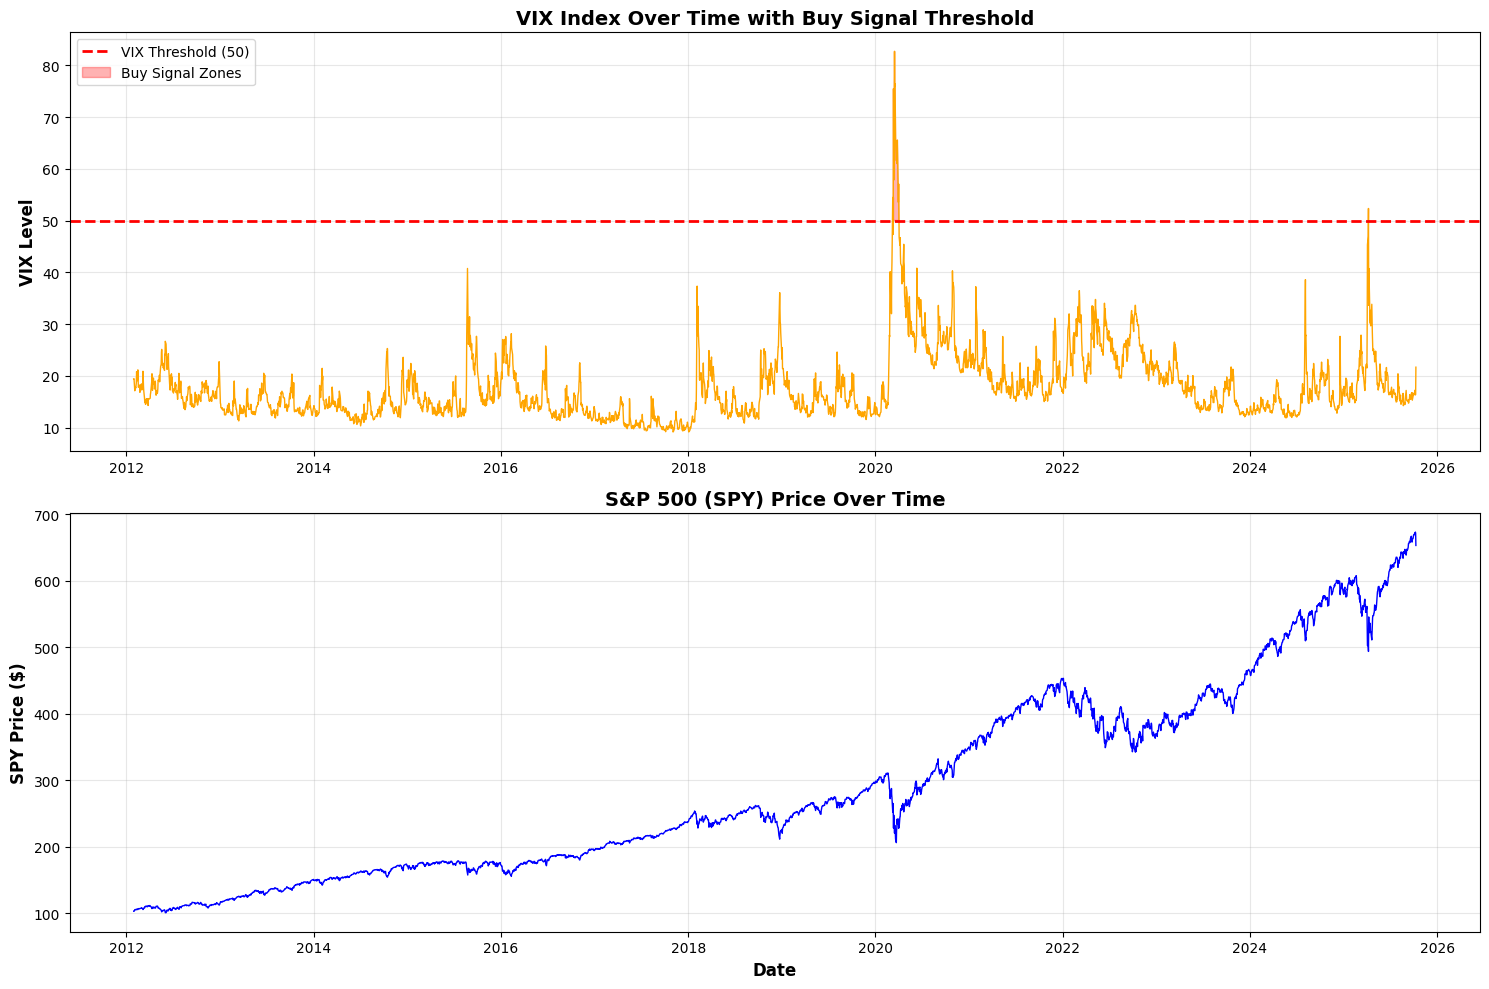

Graph 1: Historical VIX and SPY data visualization complete


In [64]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 10))

# Plot VIX
ax1.plot(df.index, df['VIX'], color='orange', linewidth=1)
ax1.axhline(y=VIX_THRESHOLD, color='red', linestyle='--', linewidth=2, label=f'VIX Threshold ({VIX_THRESHOLD})')
ax1.fill_between(df.index, VIX_THRESHOLD, df['VIX'], where=(df['VIX'] > VIX_THRESHOLD), 
                  color='red', alpha=0.3, label='Buy Signal Zones')
ax1.set_ylabel('VIX Level', fontsize=12, fontweight='bold')
ax1.set_title('VIX Index Over Time with Buy Signal Threshold', fontsize=14, fontweight='bold')
ax1.legend(loc='upper left')
ax1.grid(True, alpha=0.3)

# Plot SPY
ax2.plot(df.index, df['SPY'], color='blue', linewidth=1)
ax2.set_ylabel('SPY Price ($)', fontsize=12, fontweight='bold')
ax2.set_xlabel('Date', fontsize=12, fontweight='bold')
ax2.set_title('S&P 500 (SPY) Price Over Time', fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Graph 1: Historical VIX and SPY data visualization complete")


In [65]:
# Identify when VIX crosses above threshold (buy signals)
df['VIX_Above_Threshold'] = df['VIX'] > VIX_THRESHOLD
df['Buy_Signal'] = (df['VIX_Above_Threshold']) & (~df['VIX_Above_Threshold'].shift(1).fillna(False))

buy_dates = df[df['Buy_Signal']].index
buy_prices = df.loc[buy_dates, 'SPY'].values

print(f"\nTotal Buy Signals: {len(buy_dates)}")
print(f"\nBuy Signal Details:")
print("=" * 80)

for i, (date, price) in enumerate(zip(buy_dates, buy_prices), 1):
    vix_val = df.loc[date, 'VIX']
    print(f"{i}. {date.date()} - SPY: ${price:.2f}, VIX: {vix_val:.2f}")



Total Buy Signals: 3

Buy Signal Details:
1. 2020-03-09 - SPY: $252.04, VIX: 54.46
2. 2020-03-11 - SPY: $252.16, VIX: 53.90
3. 2025-04-08 - SPY: $493.65, VIX: 52.33


Here, we mark the locations where the signal was triggered onto the SNP 500 chart. You can see just by using volatility it becomes very easy to "buy the dip"

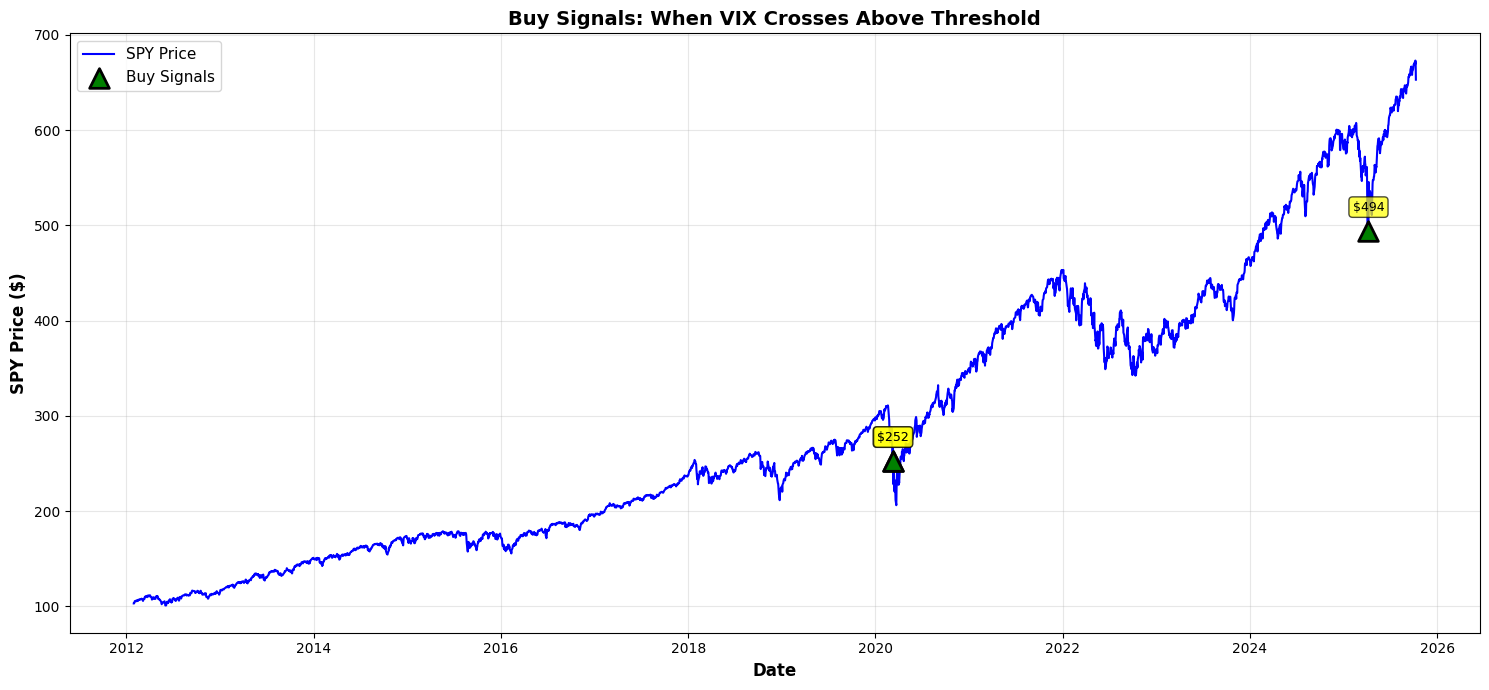

Graph 2: Buy signals visualization complete


In [66]:
fig, ax = plt.subplots(figsize=(15, 7))

ax.plot(df.index, df['SPY'], color='blue', linewidth=1.5, label='SPY Price')
ax.scatter(buy_dates, buy_prices, color='green', s=200, marker='^', 
           zorder=5, label='Buy Signals', edgecolors='black', linewidth=2)

for date, price in zip(buy_dates, buy_prices):
    ax.annotate(f'${price:.0f}', xy=(date, price), xytext=(0, 15),
                textcoords='offset points', ha='center', fontsize=9,
                bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.7))

ax.set_xlabel('Date', fontsize=12, fontweight='bold')
ax.set_ylabel('SPY Price ($)', fontsize=12, fontweight='bold')
ax.set_title('Buy Signals: When VIX Crosses Above Threshold', fontsize=14, fontweight='bold')
ax.legend(loc='upper left', fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Graph 2: Buy signals visualization complete")


Below are some stats on the strategy

In [67]:
# Initialize portfolio
portfolio = []
total_invested = 0
shares_owned = 0

for date in buy_dates:
    price = df.loc[date, 'SPY']
    shares_bought = LUMP_SUM / price
    shares_owned += shares_bought
    total_invested += LUMP_SUM
    
    portfolio.append({
        'Date': date,
        'Buy_Price': price,
        'Shares_Bought': shares_bought,
        'Total_Shares': shares_owned,
        'Total_Invested': total_invested
    })

portfolio_df = pd.DataFrame(portfolio)

# Calculate current portfolio value
current_price = df['SPY'].iloc[-1]
final_value = shares_owned * current_price
total_return = final_value - total_invested
return_pct = (total_return / total_invested) * 100 if total_invested > 0 else 0

print("\nPortfolio Summary:")
print("=" * 80)
print(f"Total Amount Invested: ${total_invested:,.2f}")
print(f"Total Shares Owned: {shares_owned:,.4f}")
print(f"Average Buy Price: ${total_invested / shares_owned:.2f}")
print(f"Current SPY Price: ${current_price:.2f}")
print(f"Current Portfolio Value: ${final_value:,.2f}")
print(f"Total Profit/Loss: ${total_return:,.2f}")
print(f"Total Return: {return_pct:.2f}%")

# Calculate holding period return
years_held = (df.index[-1] - df.index[0]).days / 365.25
if total_invested > 0:
    annualized_return = ((final_value / total_invested) ** (1/years_held) - 1) * 100
    print(f"Annualized Return: {annualized_return:.2f}%")



Portfolio Summary:
Total Amount Invested: $15,000.00
Total Shares Owned: 49.7960
Average Buy Price: $301.23
Current SPY Price: $653.02
Current Portfolio Value: $32,517.79
Total Profit/Loss: $17,517.79
Total Return: 116.79%
Annualized Return: 5.81%


In [68]:
# Cell 7: Compare with Buying Right Before Events

# Calculate when we would buy if we invested BEFORE the VIX spikes
# This simulates bad timing - buying just before a crash

print("\nStrategy Comparison:")
print("=" * 80)

# Strategy 1: VIX > 50 Strategy (buying DURING the spike)
print(f"\n1. VIX > {VIX_THRESHOLD} Strategy (Buy DURING Crisis):")
print(f"   Invested: ${total_invested:,.2f}")
print(f"   Final Value: ${final_value:,.2f}")
print(f"   Return: {return_pct:.2f}%")
print(f"   Number of Purchases: {len(buy_dates)}")

# Strategy 2: Buy RIGHT BEFORE each VIX spike (worst timing)
# For each VIX spike period, buy 5 trading days before it starts
print(f"\n2. Buy RIGHT BEFORE Crisis (Worst Timing):")

# Identify periods when VIX crosses above threshold
high_vix_events = df[df['VIX'] > VIX_THRESHOLD].copy()

if len(high_vix_events) > 0:
    # Group into distinct events
    high_vix_events['date_diff'] = high_vix_events.index.to_series().diff()
    high_vix_events['new_event'] = high_vix_events['date_diff'] > pd.Timedelta(days=5)
    high_vix_events['event_group'] = high_vix_events['new_event'].cumsum()
    
    # Get the start date of each event
    event_starts = high_vix_events.groupby('event_group').first()
    
    # Buy 5 trading days before each event
    before_event_dates = []
    before_event_prices = []
    
    for event_start in event_starts.index:
        event_date = high_vix_events[high_vix_events['event_group'] == event_start].index[0]
        # Find 5 trading days before
        all_dates = df.index[df.index < event_date]
        if len(all_dates) >= 5:
            buy_before_date = all_dates[-5]
            before_event_dates.append(buy_before_date)
            before_event_prices.append(df.loc[buy_before_date, 'SPY'])
    
    # Calculate returns for buying before events
    before_invested = len(before_event_dates) * LUMP_SUM
    before_shares = sum(LUMP_SUM / price for price in before_event_prices)
    before_value = before_shares * current_price
    before_return_pct = ((before_value / before_invested) - 1) * 100 if before_invested > 0 else 0
    
    print(f"   Invested: ${before_invested:,.2f}")
    print(f"   Final Value: ${before_value:,.2f}")
    print(f"   Return: {before_return_pct:.2f}%")
    print(f"   Number of Purchases: {len(before_event_dates)}")
    
    print(f"\n   Purchase Details (5 days before VIX spike):")
    for i, (date, price) in enumerate(zip(before_event_dates, before_event_prices), 1):
        spike_date = high_vix_events[high_vix_events['event_group'] == i-1].index[0]
        days_later = (spike_date - date).days
        spike_vix = df.loc[spike_date, 'VIX']
        print(f"   {i}. {date.date()} at ${price:.2f} (VIX spike to {spike_vix:.1f} occurred {days_later} days later)")

# Strategy 3: Buy RIGHT AFTER each VIX spike peaks (buying the dip)
print(f"\n3. Buy RIGHT AFTER VIX Peak (Buy the Dip):")

if len(high_vix_events) > 0:
    # For each event, find the peak VIX day and buy 1 day after
    after_peak_dates = []
    after_peak_prices = []
    
    for event_id in high_vix_events['event_group'].unique():
        event_data = high_vix_events[high_vix_events['event_group'] == event_id]
        peak_vix_date = event_data['VIX'].idxmax()
        
        # Buy 1 trading day after peak
        all_dates = df.index[df.index > peak_vix_date]
        if len(all_dates) >= 1:
            buy_after_date = all_dates[0]
            after_peak_dates.append(buy_after_date)
            after_peak_prices.append(df.loc[buy_after_date, 'SPY'])
    
    # Calculate returns
    after_invested = len(after_peak_dates) * LUMP_SUM
    after_shares = sum(LUMP_SUM / price for price in after_peak_prices)
    after_value = after_shares * current_price
    after_return_pct = ((after_value / after_invested) - 1) * 100 if after_invested > 0 else 0
    
    print(f"   Invested: ${after_invested:,.2f}")
    print(f"   Final Value: ${after_value:,.2f}")
    print(f"   Return: {after_return_pct:.2f}%")
    print(f"   Number of Purchases: {len(after_peak_dates)}")

# Strategy 4: Buy and Hold from start
buy_hold_invested = total_invested
first_price = df['SPY'].iloc[0]
buy_hold_shares = buy_hold_invested / first_price
buy_hold_value = buy_hold_shares * current_price
buy_hold_return = ((buy_hold_value / buy_hold_invested) - 1) * 100

print(f"\n4. Buy and Hold from Start:")
print(f"   Invested: ${buy_hold_invested:,.2f} (all at once in {df.index[0].date()})")
print(f"   Final Value: ${buy_hold_value:,.2f}")
print(f"   Return: {buy_hold_return:.2f}%")

# Summary comparison
print("\n" + "=" * 80)
print("RETURN COMPARISON")
print("=" * 80)
strategies_comparison = [
    ("VIX > 50 (During Crisis)", return_pct),
    ("Before Crisis (-5 days)", before_return_pct),
    ("After VIX Peak (+1 day)", after_return_pct),
    ("Buy & Hold", buy_hold_return)
]

# Sort by return
strategies_comparison.sort(key=lambda x: x[1], reverse=True)

for i, (strategy, ret) in enumerate(strategies_comparison, 1):
    emoji = "🥇" if i == 1 else "🥈" if i == 2 else "🥉" if i == 3 else "  "
    print(f"{emoji} {i}. {strategy:30s} {ret:+7.2f}%")



Strategy Comparison:

1. VIX > 50 Strategy (Buy DURING Crisis):
   Invested: $15,000.00
   Final Value: $32,517.79
   Return: 116.79%
   Number of Purchases: 3

2. Buy RIGHT BEFORE Crisis (Worst Timing):
   Invested: $10,000.00
   Final Value: $17,347.61
   Return: 73.48%
   Number of Purchases: 2

   Purchase Details (5 days before VIX spike):
   1. 2020-03-02 at $284.08 (VIX spike to 54.5 occurred 7 days later)
   2. 2025-04-01 at $557.77 (VIX spike to 52.3 occurred 7 days later)

3. Buy RIGHT AFTER VIX Peak (Buy the Dip):
   Invested: $10,000.00
   Final Value: $20,038.66
   Return: 100.39%
   Number of Purchases: 2

4. Buy and Hold from Start:
   Invested: $15,000.00 (all at once in 2012-01-30)
   Final Value: $95,183.85
   Return: 534.56%

RETURN COMPARISON
🥇 1. Buy & Hold                     +534.56%
🥈 2. VIX > 50 (During Crisis)       +116.79%
🥉 3. After VIX Peak (+1 day)        +100.39%
   4. Before Crisis (-5 days)         +73.48%


So, this strategy seems to outperform other attempts to outperform the market, both after vix peak and before crisis which is the worst possible timing

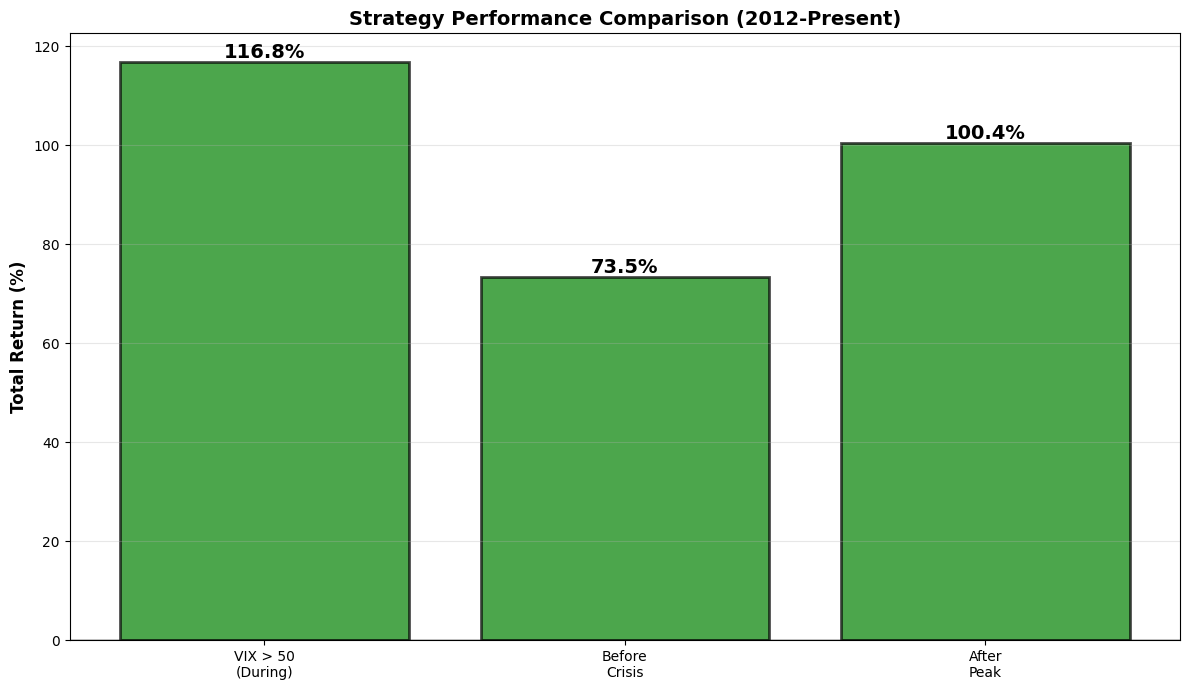

Graph 3: Strategy comparison visualization complete


In [69]:
# Cell 8: Visualize Strategy Comparison
# ============================================================================

strategies = ['VIX > 50\n(During)', 'Before\nCrisis', 'After\nPeak']
returns = [return_pct, before_return_pct, after_return_pct]
colors = ['green' if r > 0 else 'red' for r in returns]

fig, ax = plt.subplots(figsize=(12, 7))
bars = ax.bar(strategies, returns, color=colors, alpha=0.7, edgecolor='black', linewidth=2)

for bar, ret in zip(bars, returns):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{ret:.1f}%', ha='center', va='bottom' if ret > 0 else 'top',
            fontsize=14, fontweight='bold')

ax.axhline(y=0, color='black', linestyle='-', linewidth=1)
ax.set_ylabel('Total Return (%)', fontsize=12, fontweight='bold')
ax.set_title('Strategy Performance Comparison (2012-Present)', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("Graph 3: Strategy comparison visualization complete")



Plotting portfolio values starting from: 2020-03-02
(First non-zero investment date)


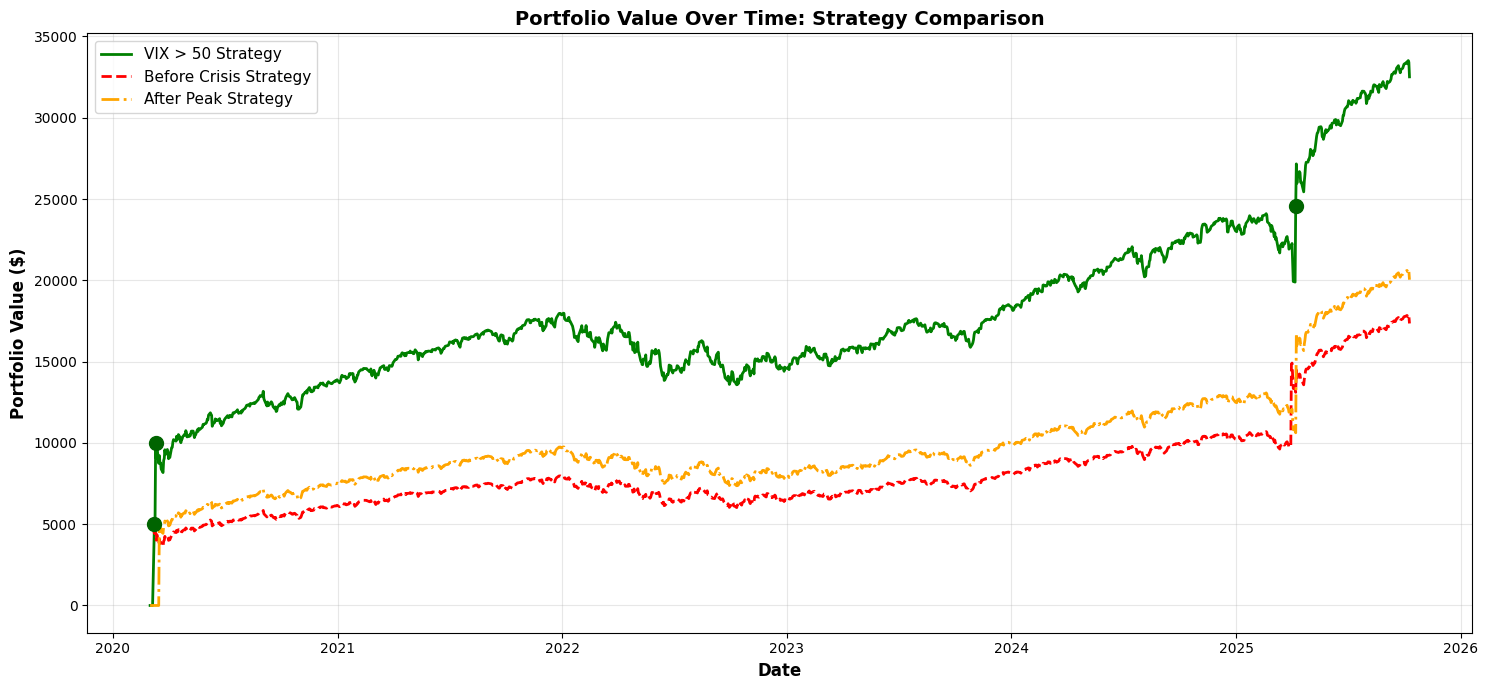

Graph 4: Portfolio value over time visualization complete


In [70]:
# Cell 9: Portfolio Value Over Time
# ============================================================================

# Calculate portfolio value over time for each strategy
dates_list = df.index

# VIX > 50 Strategy
vix_portfolio_values = []
for date in dates_list:
    shares_at_date = portfolio_df[portfolio_df['Date'] <= date]['Total_Shares'].iloc[-1] \
                     if len(portfolio_df[portfolio_df['Date'] <= date]) > 0 else 0
    vix_portfolio_values.append(shares_at_date * df.loc[date, 'SPY'])

# Before Crisis Strategy
before_portfolio_values = []
before_shares_cum = 0
for date in dates_list:
    if date in before_event_dates:
        idx = before_event_dates.index(date)
        before_shares_cum += LUMP_SUM / before_event_prices[idx]
    before_portfolio_values.append(before_shares_cum * df.loc[date, 'SPY'])

# After Peak Strategy
after_portfolio_values = []
after_shares_cum = 0
for date in dates_list:
    if date in after_peak_dates:
        idx = after_peak_dates.index(date)
        after_shares_cum += LUMP_SUM / after_peak_prices[idx]
    after_portfolio_values.append(after_shares_cum * df.loc[date, 'SPY'])

# Buy and Hold
buy_hold_values = [buy_hold_shares * price for price in df['SPY']]

# Find the first date when any non-buy-hold strategy has a non-zero value
first_investment_date = None
for i, date in enumerate(dates_list):
    if vix_portfolio_values[i] > 0 or before_portfolio_values[i] > 0 or after_portfolio_values[i] > 0:
        first_investment_date = date
        break

# If we found a first investment date, filter the data
if first_investment_date is not None:
    # Find the index
    start_idx = dates_list.get_loc(first_investment_date)
    
    # Slice all data from that point
    plot_dates = dates_list[start_idx:]
    plot_vix_values = vix_portfolio_values[start_idx:]
    plot_before_values = before_portfolio_values[start_idx:]
    plot_after_values = after_portfolio_values[start_idx:]
    plot_buy_hold_values = buy_hold_values[start_idx:]
    
    print(f"\nPlotting portfolio values starting from: {first_investment_date.date()}")
    print(f"(First non-zero investment date)")
else:
    # No investments made, use all data
    plot_dates = dates_list
    plot_vix_values = vix_portfolio_values
    plot_before_values = before_portfolio_values
    plot_after_values = after_portfolio_values
    plot_buy_hold_values = buy_hold_values
    print("\nNo investments detected, plotting full range")

fig, ax = plt.subplots(figsize=(15, 7))

ax.plot(plot_dates, plot_vix_values, label='VIX > 50 Strategy', linewidth=2, color='green')
ax.plot(plot_dates, plot_before_values, label='Before Crisis Strategy', linewidth=2, color='red', linestyle='--')
ax.plot(plot_dates, plot_after_values, label='After Peak Strategy', linewidth=2, color='orange', linestyle='-.')


# Mark investment points for VIX strategy (only those in the plot range)
for date in buy_dates:
    if date >= first_investment_date:
        idx = plot_dates.get_loc(date)
        ax.scatter(date, plot_vix_values[idx], color='darkgreen', s=100, zorder=5)

ax.set_xlabel('Date', fontsize=12, fontweight='bold')
ax.set_ylabel('Portfolio Value ($)', fontsize=12, fontweight='bold')
ax.set_title('Portfolio Value Over Time: Strategy Comparison', fontsize=14, fontweight='bold')
ax.legend(loc='upper left', fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Graph 4: Portfolio value over time visualization complete")


In [71]:
# Cell 10: Performance Metrics Table
# ============================================================================

metrics_data = {
    'Metric': [
        'Total Invested',
        'Final Value',
        'Total Return ($)',
        'Total Return (%)',
        'Number of Trades',
        'Avg Purchase Price',
        'Current Price'
    ],
    'VIX > 50': [
        f'${total_invested:,.2f}',
        f'${final_value:,.2f}',
        f'${total_return:,.2f}',
        f'{return_pct:.2f}%',
        f'{len(buy_dates)}',
        f'${total_invested / shares_owned:.2f}' if shares_owned > 0 else 'N/A',
        f'${current_price:.2f}'
    ],
    'Before Crisis': [
        f'${before_invested:,.2f}',
        f'${before_value:,.2f}',
        f'${before_value - before_invested:,.2f}',
        f'{before_return_pct:.2f}%',
        f'{len(before_event_dates)}',
        f'${before_invested / before_shares:.2f}',
        f'${current_price:.2f}'
    ],
    'After Peak': [
        f'${after_invested:,.2f}',
        f'${after_value:,.2f}',
        f'${after_value - after_invested:,.2f}',
        f'{after_return_pct:.2f}%',
        f'{len(after_peak_dates)}',
        f'${after_invested / after_shares:.2f}',
        f'${current_price:.2f}'
    ],
    'Buy & Hold': [
        f'${buy_hold_invested:,.2f}',
        f'${buy_hold_value:,.2f}',
        f'${buy_hold_value - buy_hold_invested:,.2f}',
        f'{buy_hold_return:.2f}%',
        '1',
        f'${first_price:.2f}',
        f'${current_price:.2f}'
    ]
}

metrics_df = pd.DataFrame(metrics_data)
print("\nDetailed Performance Metrics:")
print("=" * 120)
print(metrics_df.to_string(index=False))

# Save results
metrics_df.to_csv('backtest_results_2012onwards.csv', index=False)
portfolio_df.to_csv('portfolio_transactions_2012onwards.csv', index=False)

print("\n\nResults saved to:")
print("  - backtest_results_2012onwards.csv")
print("  - portfolio_transactions_2012onwards.csv")

print("\n" + "=" * 80)
print("✓ BACKTEST COMPLETE!")
print("=" * 80)



Detailed Performance Metrics:
            Metric   VIX > 50 Before Crisis After Peak Buy & Hold
    Total Invested $15,000.00    $10,000.00 $10,000.00 $15,000.00
       Final Value $32,517.79    $17,347.61 $20,038.66 $95,183.85
  Total Return ($) $17,517.79     $7,347.61 $10,038.66 $80,183.85
  Total Return (%)    116.79%        73.48%    100.39%    534.56%
  Number of Trades          3             2          2          1
Avg Purchase Price    $301.23       $376.43    $325.88    $102.91
     Current Price    $653.02       $653.02    $653.02    $653.02


Results saved to:
  - backtest_results_2012onwards.csv
  - portfolio_transactions_2012onwards.csv

✓ BACKTEST COMPLETE!


So, does this strategy outperform buying and holding? Can we use our vix strategy alone to outperform the market?
### Downsides:
This strategy only performs a signal twice, i will soon update it to update for other vix levels for more entry opportunitites. This strategy is clearly best supported in tandem with a buy and hold strategy: dollar cost averaging during periods of normal volatilty and occasionally providing lump sum entries during high volatility periods